In [1]:
import sys
sys.path.append("../../..")
from utils.processing import json_file_access
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde, mode

In [2]:
res_all = {}

configuration = {
    "cs_methods": ["LFMLocal", "GCE", "LocalTightnessExpansion","TCE","PageRankNibble"],
    "cs_core_node_number": [10,20,30]
}

# Iteratively add CS Top100
for cs in configuration["cs_methods"]:
    for cs_core_no in configuration["cs_core_node_number"]:
        res_all[cs + "_" + str(cs_core_no)] = json_file_access(f"../../../05_results/rq2/cs/kg2_results_rq2_cs_{cs}_{cs_core_no}_all_community.json","r")

In [3]:
c_size = defaultdict(dict)

for cs, values in res_all.items():
    for ir_type, queries in values.items():
        c_size[cs][ir_type] = []
        for query in queries.keys():
            c_size[cs][ir_type].append(len(queries[query]))

In [4]:
def approximate_pdf(data):
    kde = gaussian_kde(data)
    x_values = np.linspace(data.min(), data.max(), 1000)  # Define x-axis range
    pdf_values = kde(x_values)

    mean = np.mean(data)
    median_value = np.median(data)
    mode_value = mode(data)[0]
    return x_values, pdf_values, mean, median_value, mode_value

In [5]:
def convert_cs_titles(title):
    split_title = title.split("_")
    if split_title[0] == "LFMLocal":
        return "LFM-" + split_title[1]
    elif split_title[0] == "GCE":
        return "GCE-" + split_title[1]
    elif split_title[0] == "LocalTightnessExpansion":
        return "LTE-" + split_title[1]
    elif split_title[0] == "TCE":
        return "TCE-" + split_title[1]
    elif split_title[0] == "PageRankNibble":
        return "PRN-" + split_title[1]

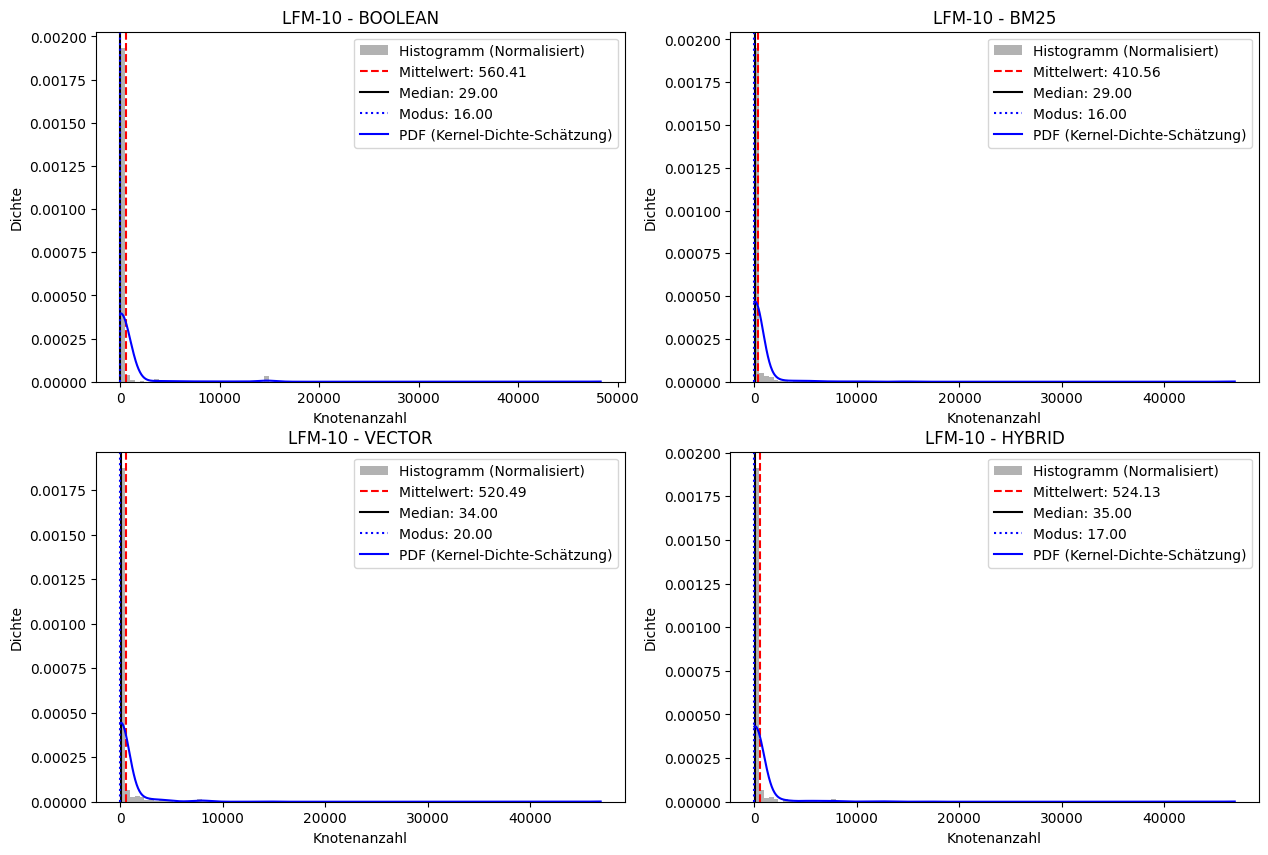

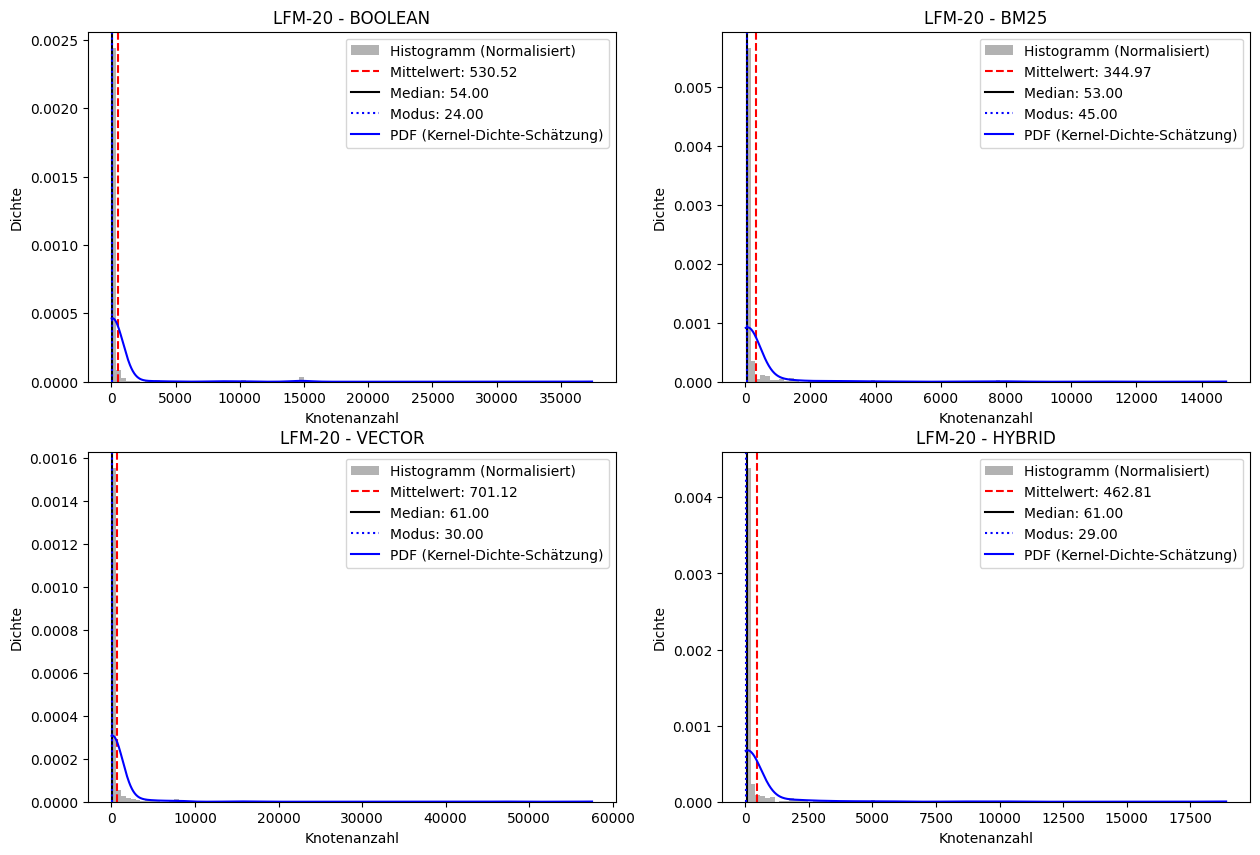

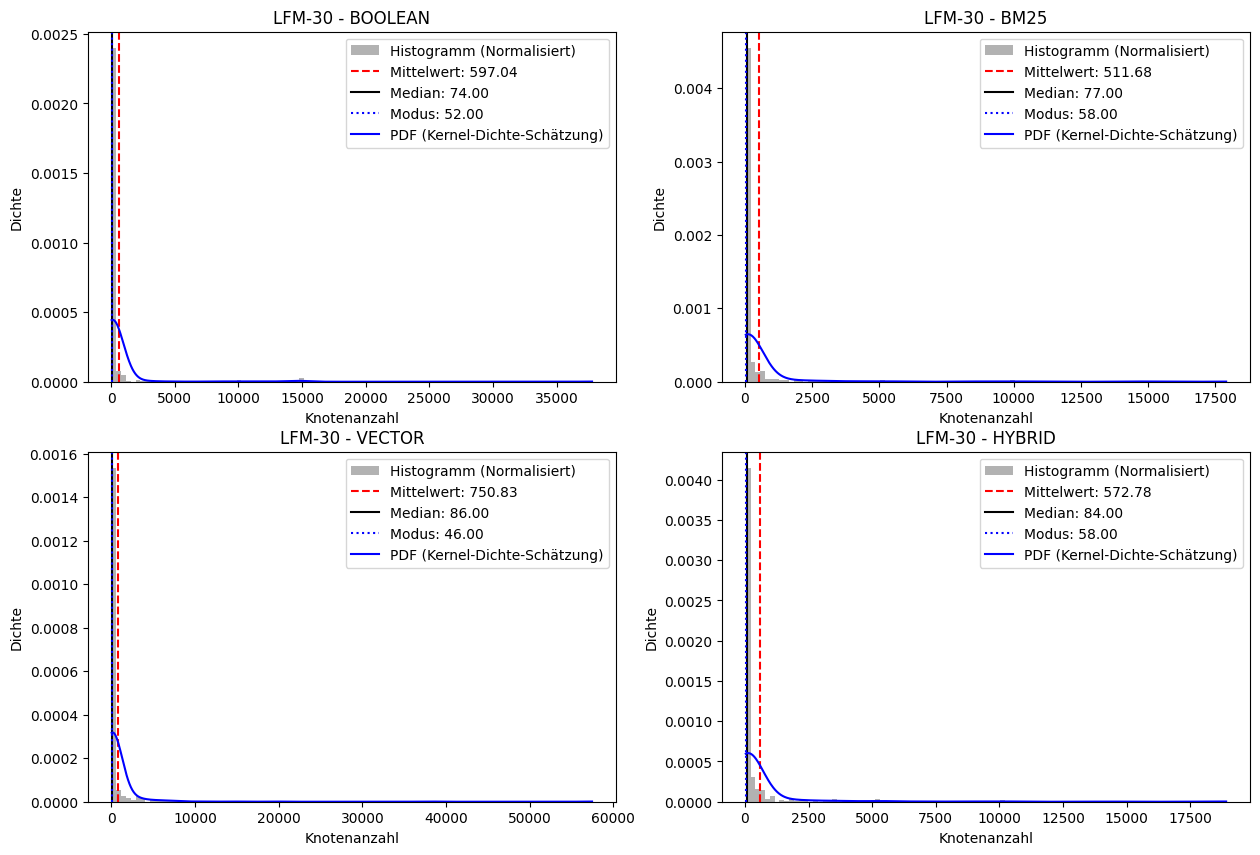

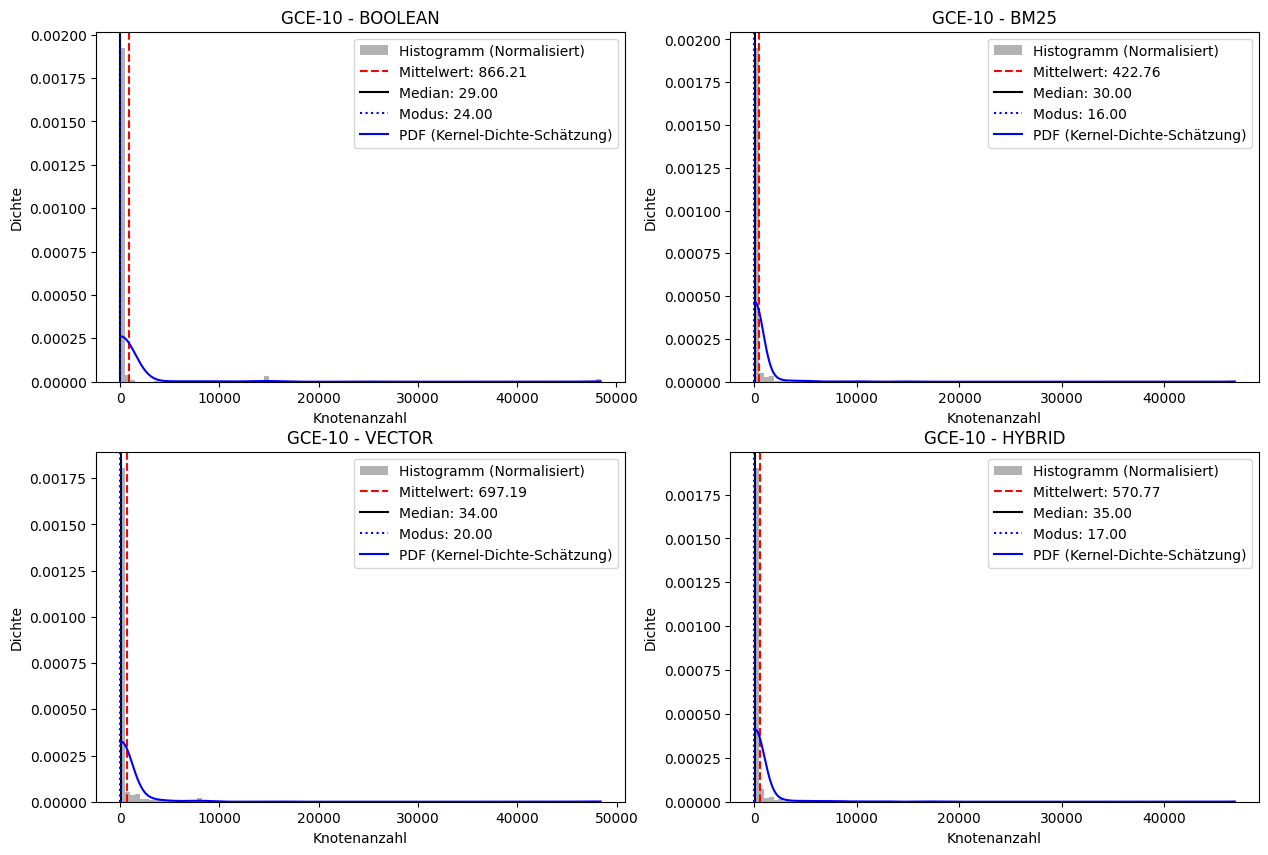

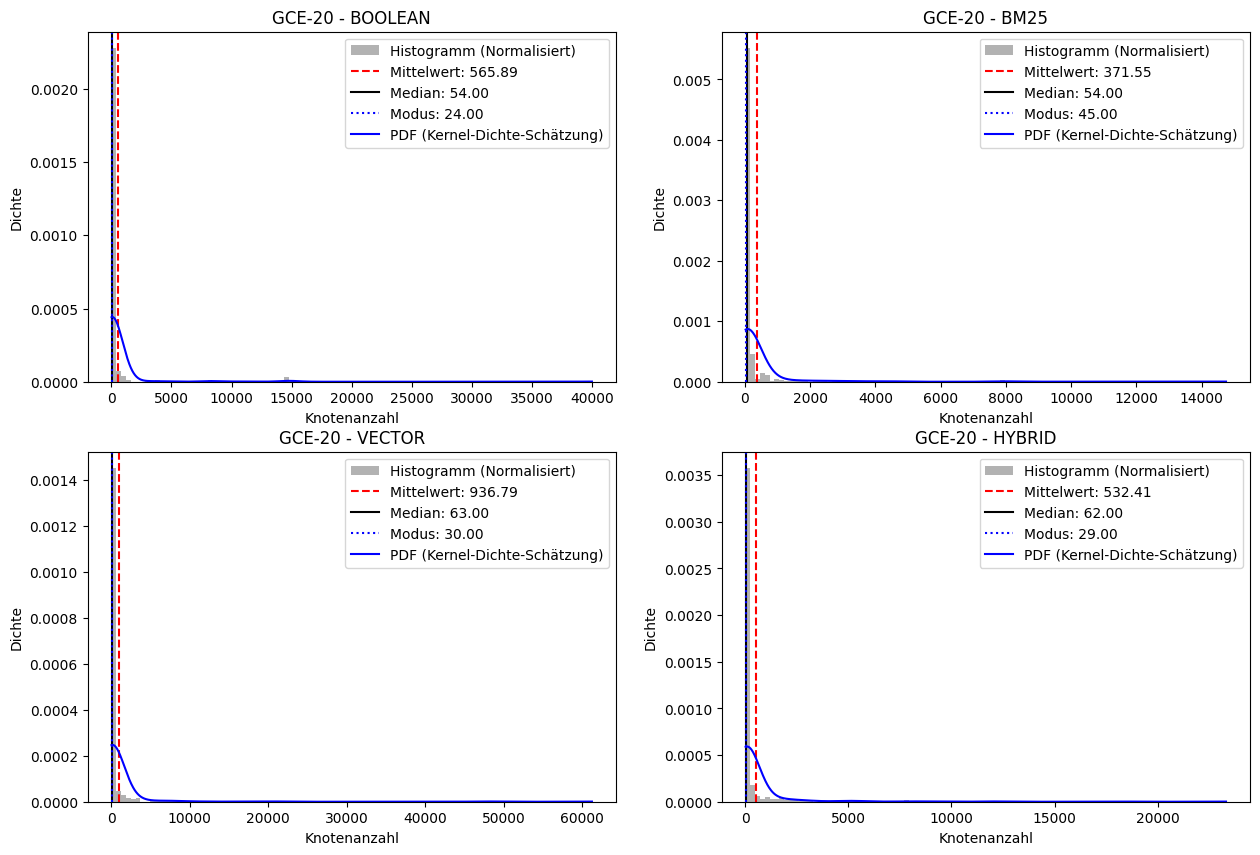

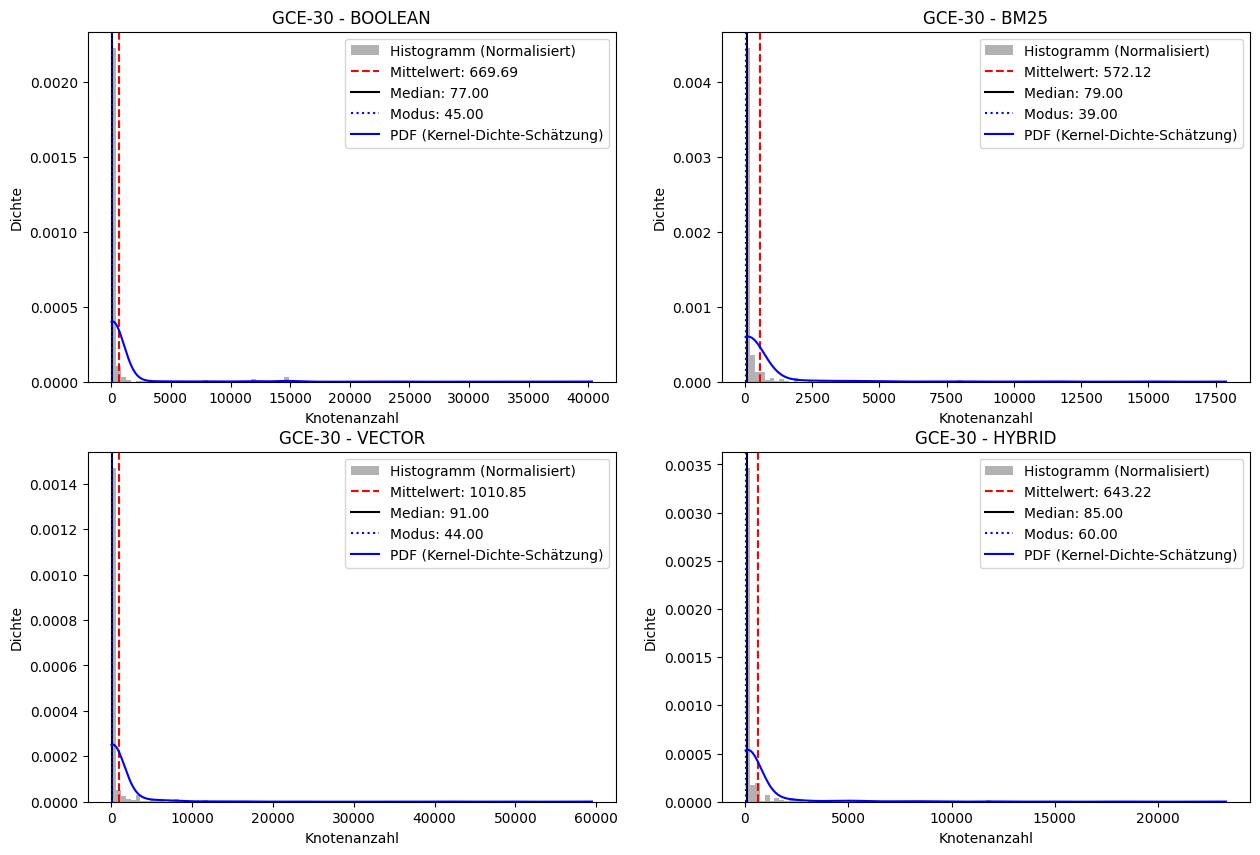

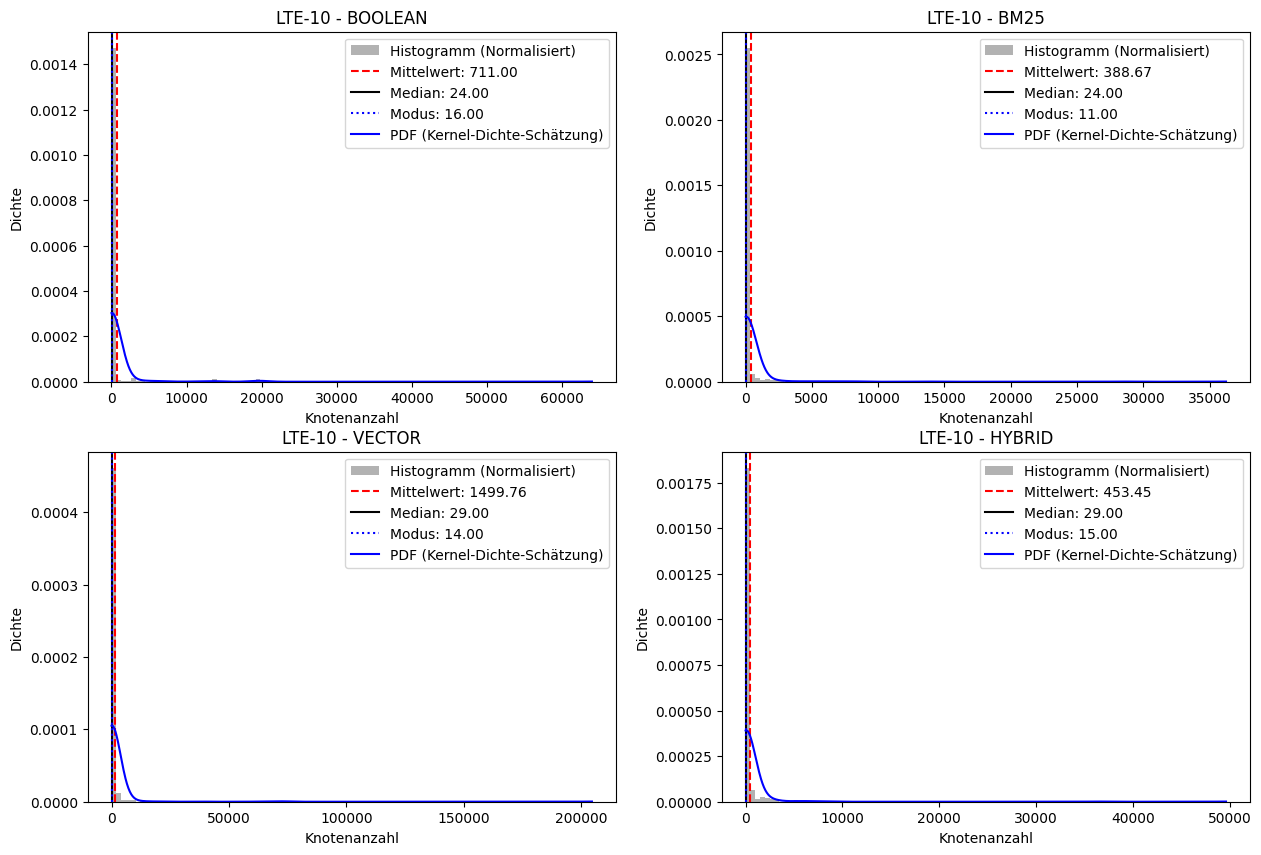

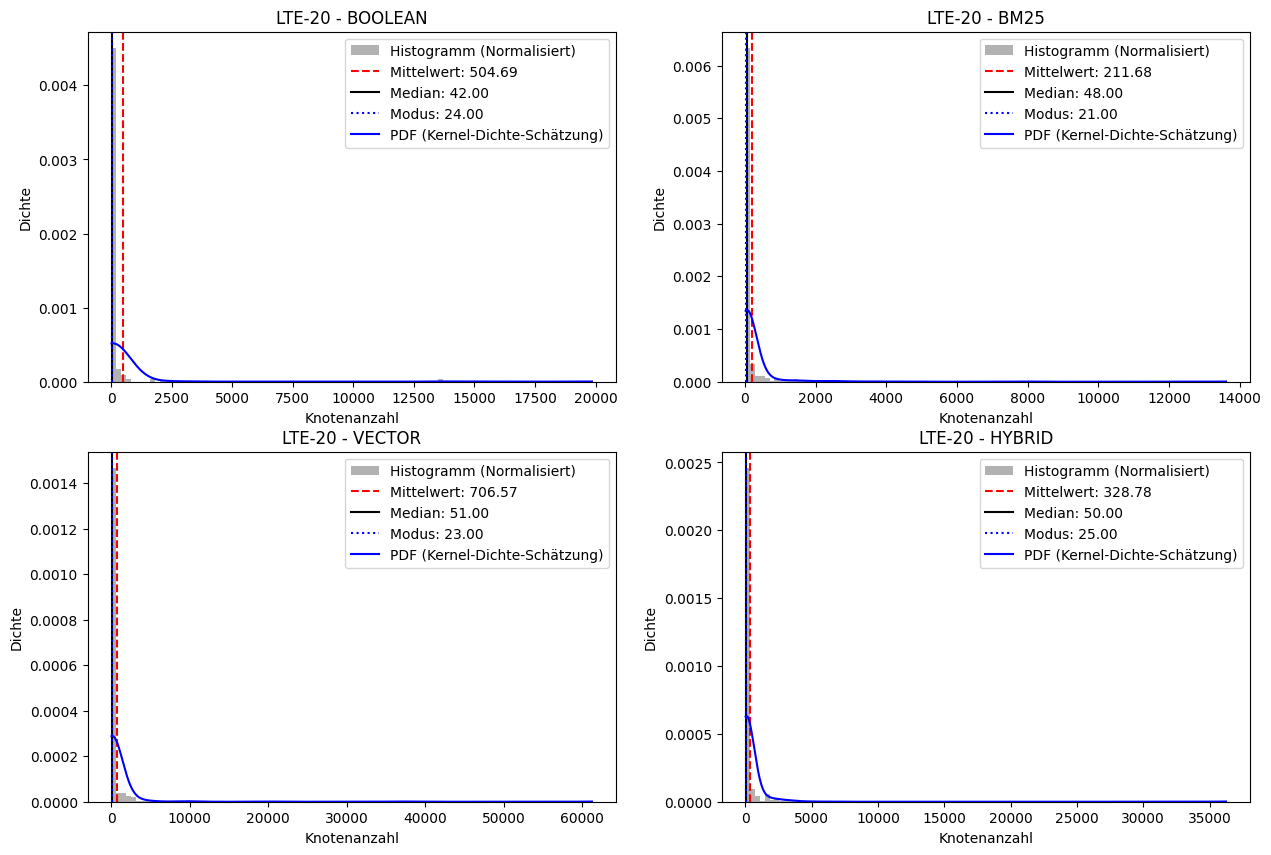

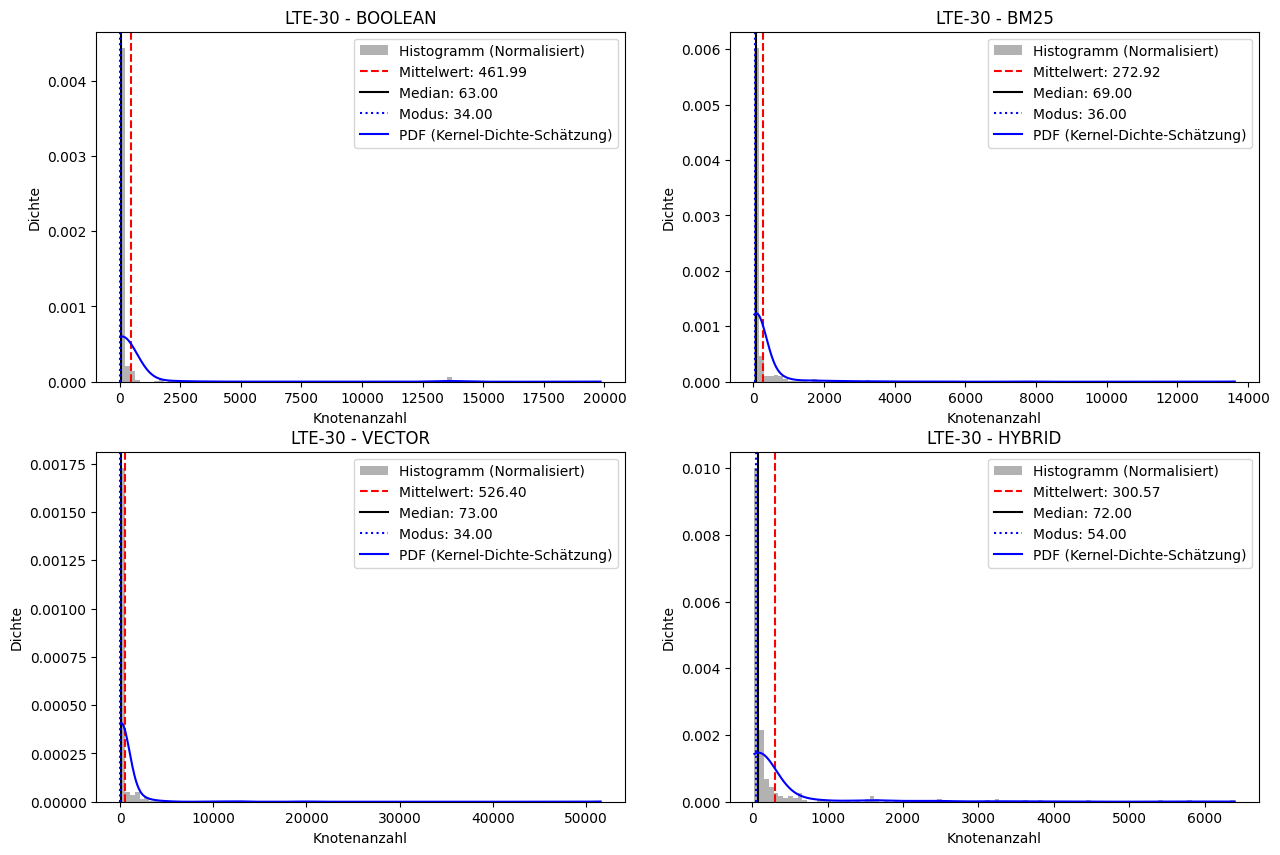

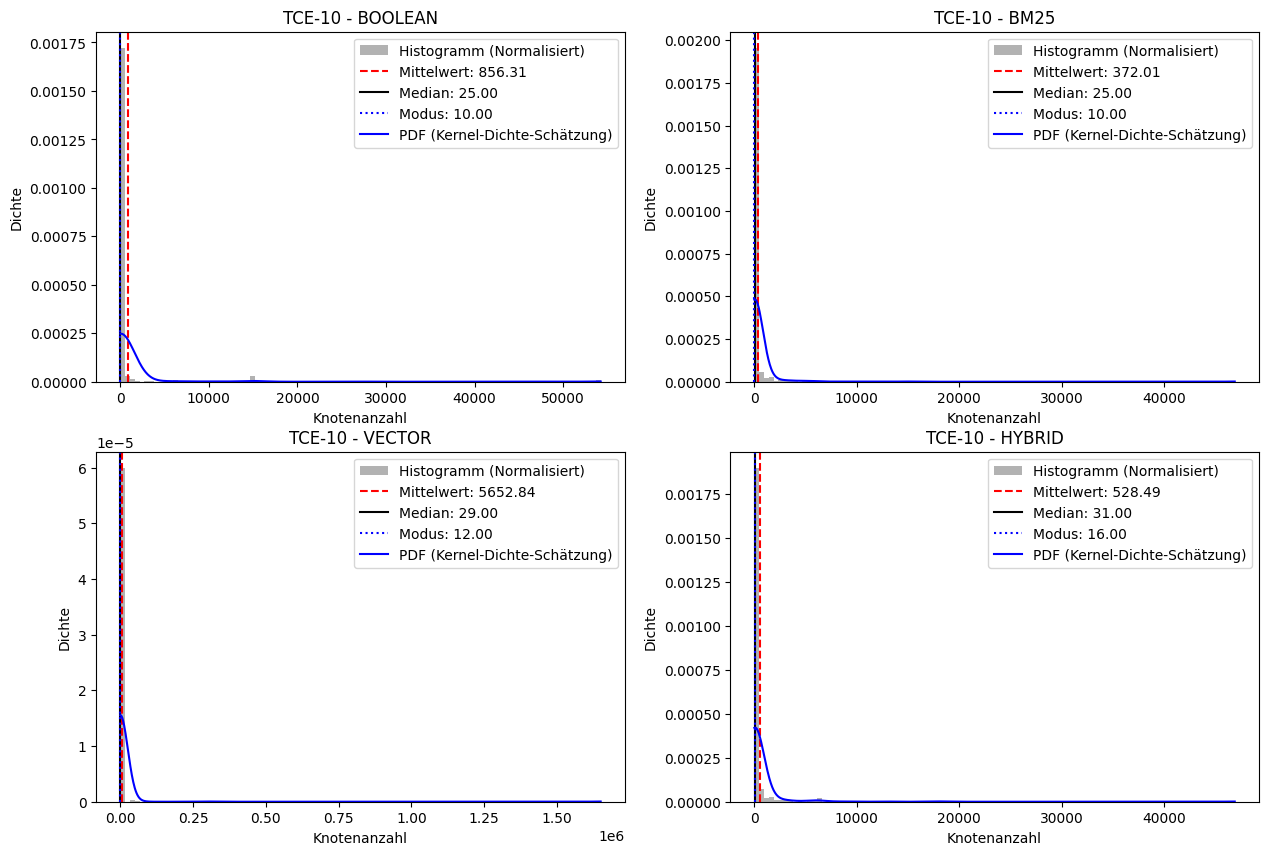

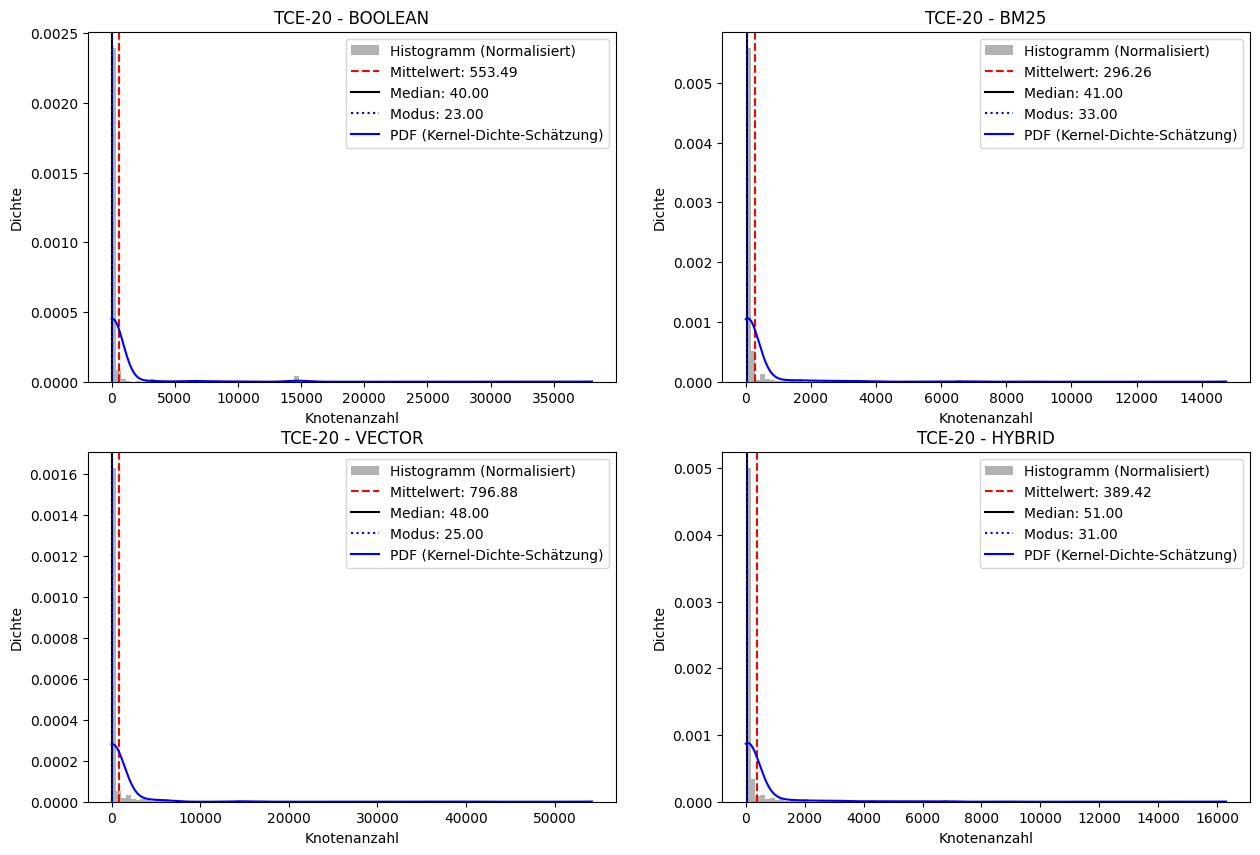

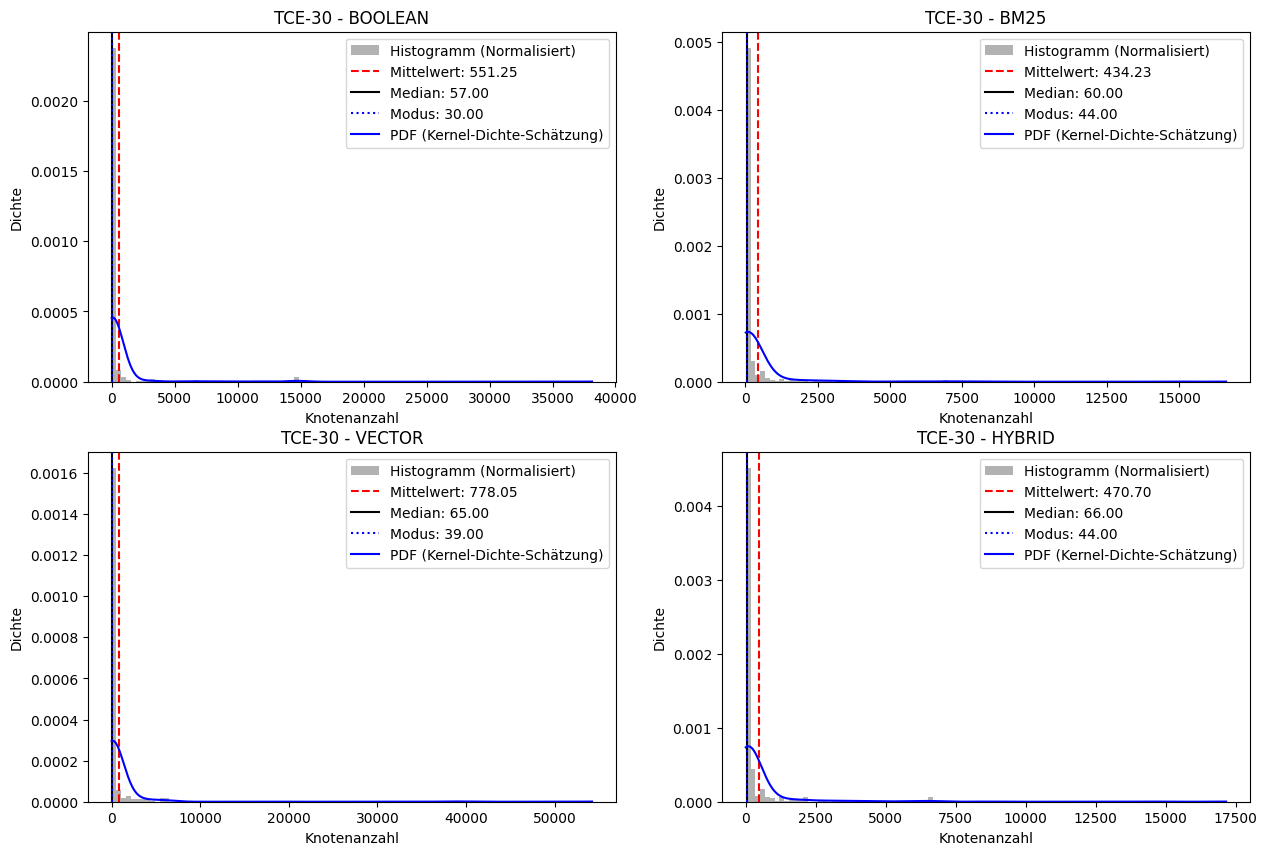

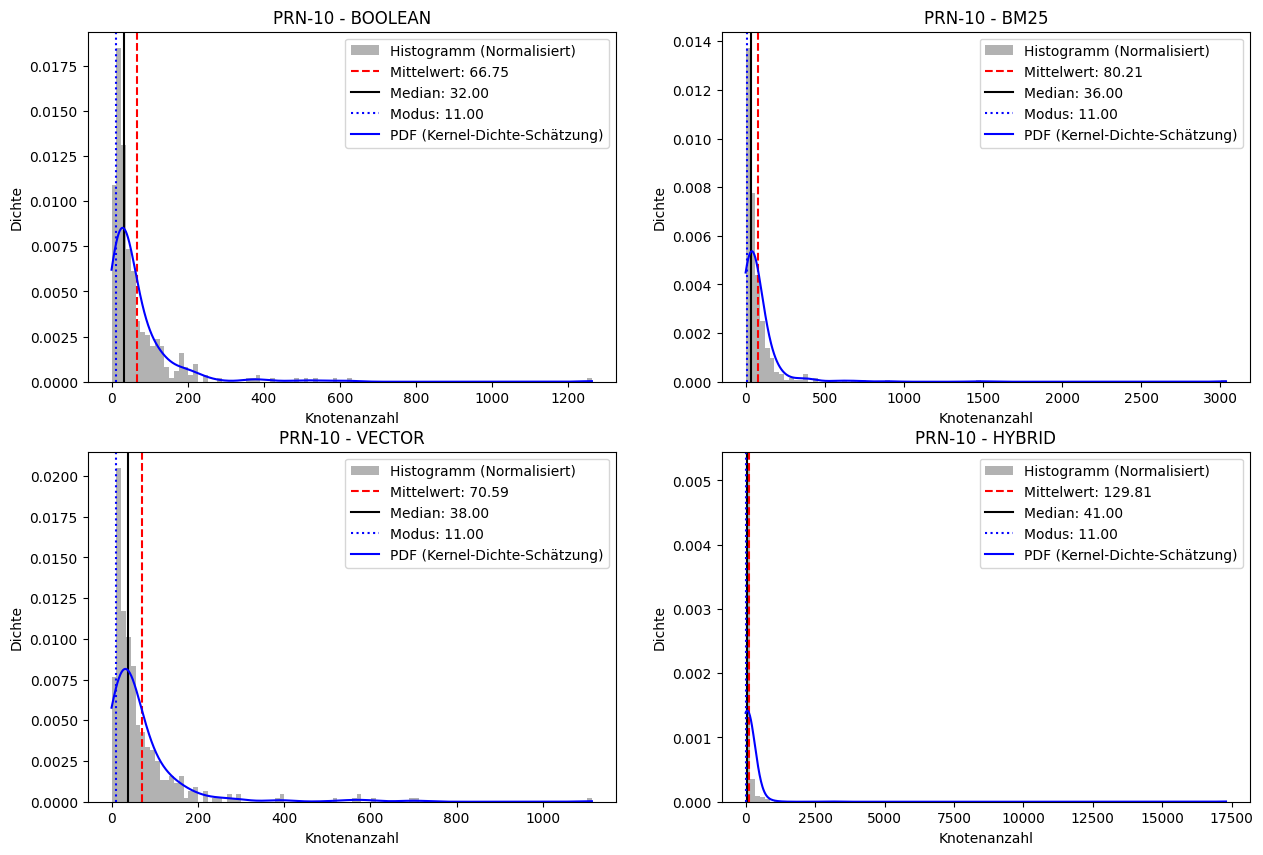

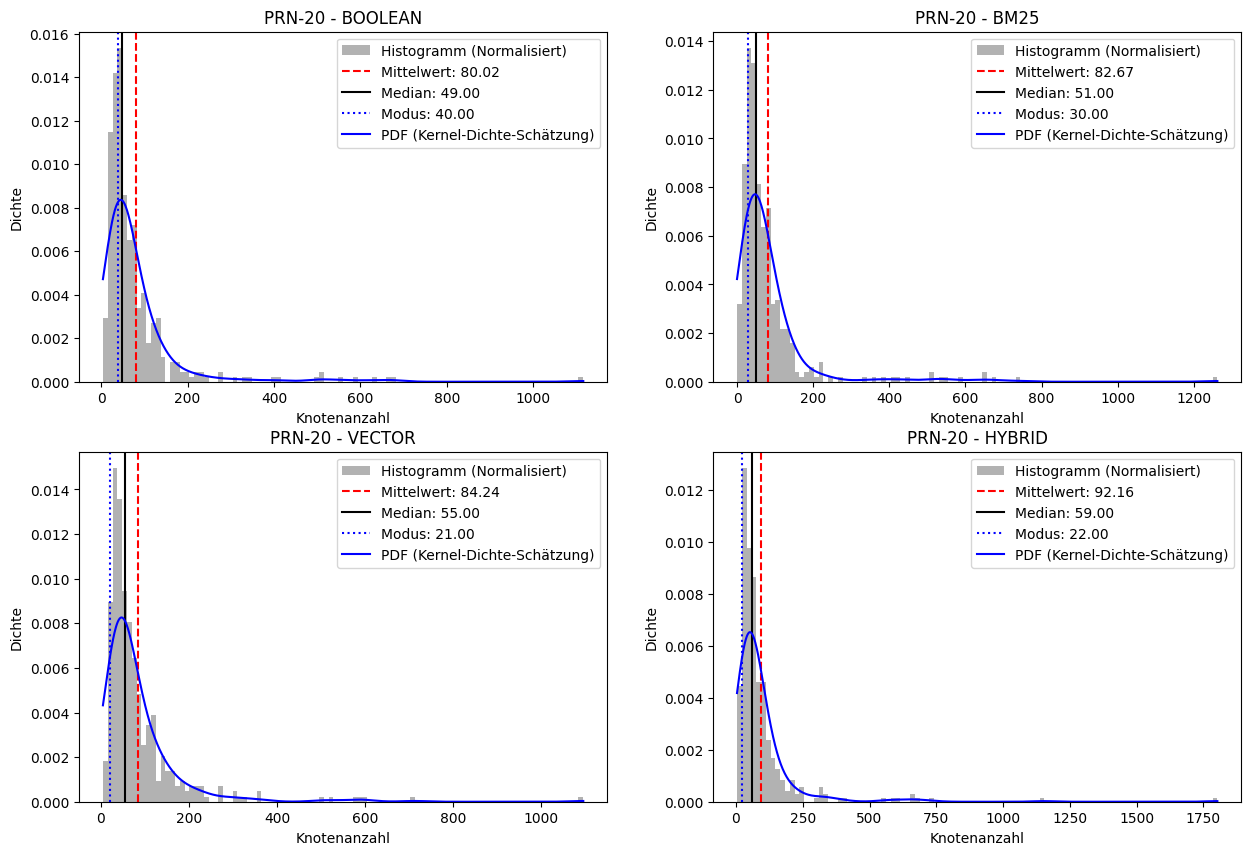

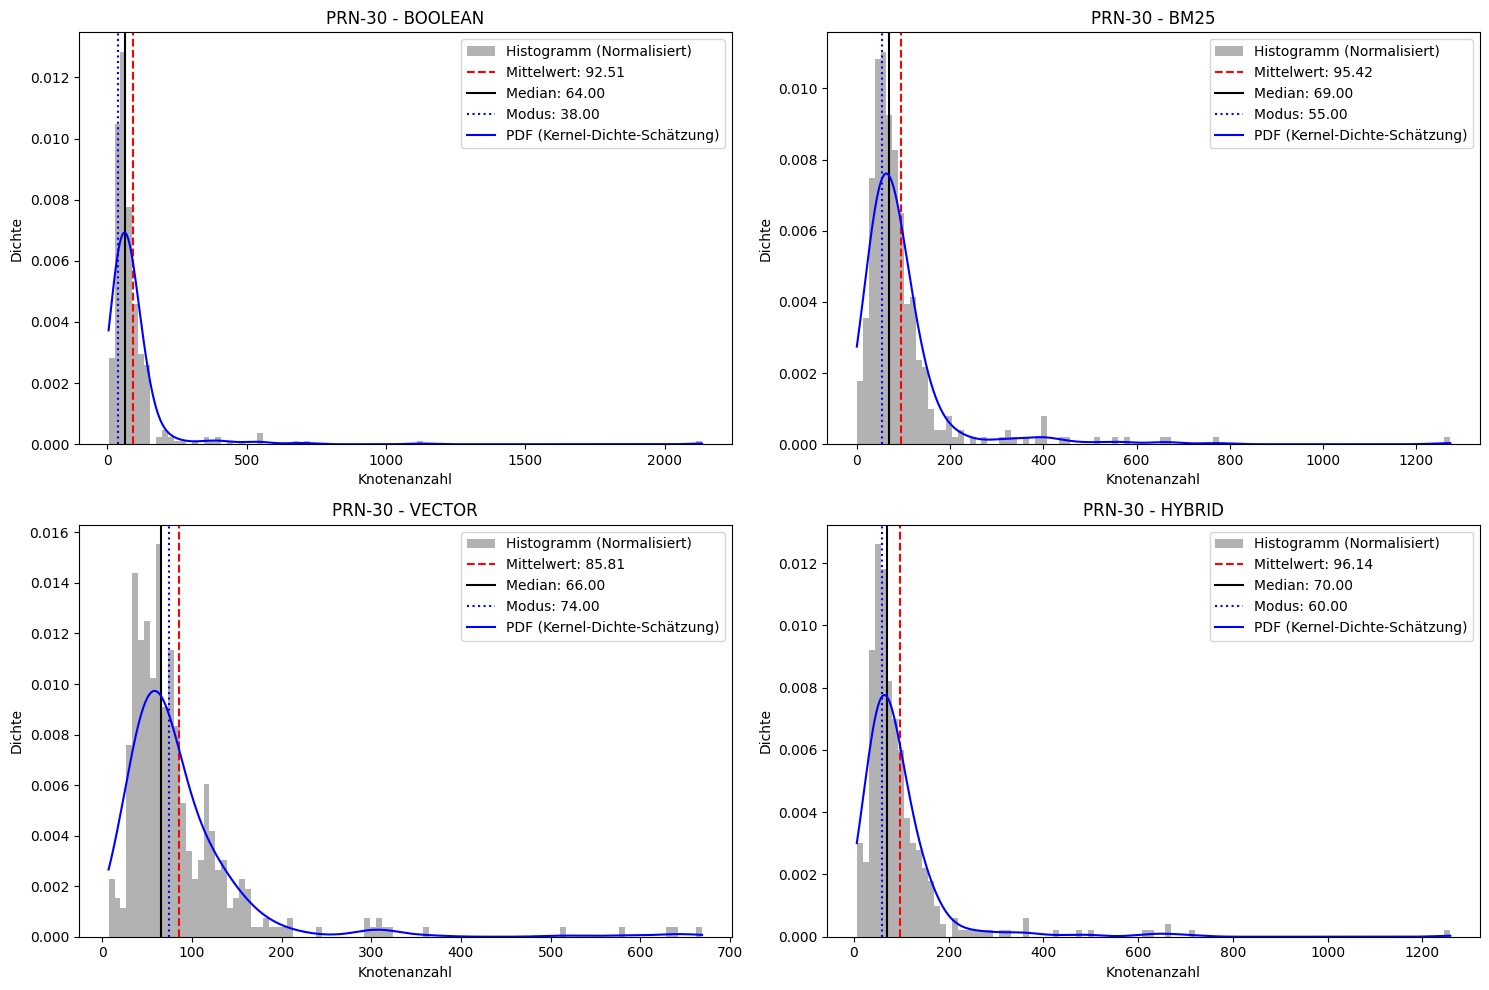

In [6]:
# Abbildung 33 sowie Anhänge B19-B32
for cs, values in res_all.items():
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
    for j, ir_type in enumerate(values.keys()):
        data_array = np.array(c_size[cs][ir_type])
        x_values, pdf_values, mean, median_value, mode_value = approximate_pdf(data_array)
# Plot the PDF
        if j == 0:
            ax = axs[0,0]
        elif j == 1:
            ax = axs[0,1]
        elif j == 2:
            ax = axs[1,0]
        elif j == 3:
            ax = axs[1,1]

        #bin_count = int((np.max(data_array)/mean) * 5)

        ax.hist(data_array, bins=100, density=True, alpha=0.6, color='gray', label='Histogramm (Normalisiert)')
        ax.axvline(mean, color='r', linestyle='--', label=f'Mittelwert: {mean:.2f}')
        ax.axvline(median_value, color='black', linestyle='-', label=f'Median: {median_value:.2f}')
        ax.axvline(mode_value, color='b', linestyle=':', label=f'Modus: {mode_value:.2f}')
        ax.plot(x_values, pdf_values, label="PDF (Kernel-Dichte-Schätzung)", color="blue")
        ax.set_title(f"{convert_cs_titles(cs)} - {ir_type.upper()}")
        ax.set_xlabel("Knotenanzahl")
        ax.set_ylabel("Dichte")
        #ax.set_xlim(0, int(mean * 10))
        ax.grid(False)
        ax.legend()
    plt.savefig(f"RQ2_KG2_pdf_{cs}.svg")
plt.tight_layout()
plt.show()